In [2]:
!pip install -q albumentations==1.3.1 timm grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 65.2 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 10.9 MB/s eta 0:00:00


In [3]:
import os, cv2, copy, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, classification_report,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, confusion_matrix
)

BASE_DIR  = '/kaggle/input/datasets/andrewmvd/retinal-disease-classification'
TRAIN_IMG = os.path.join(BASE_DIR, 'Training_Set/Training_Set/Training')
VAL_IMG   = os.path.join(BASE_DIR, 'Evaluation_Set/Evaluation_Set/Validation')
TEST_IMG  = os.path.join(BASE_DIR, 'Test_Set/Test_Set/Test')
TRAIN_CSV = os.path.join(BASE_DIR, 'Training_Set/Training_Set/RFMiD_Training_Labels.csv')
VAL_CSV   = os.path.join(BASE_DIR, 'Evaluation_Set/Evaluation_Set/RFMiD_Validation_Labels.csv')
TEST_CSV  = os.path.join(BASE_DIR, 'Test_Set/Test_Set/RFMiD_Testing_Labels.csv')

DISEASE_COLS = ['DR', 'ARMD', 'MH', 'DN', 'MYA', 'TSLN']
IMAGE_SIZE   = 224
BATCH_SIZE   = 16
NUM_EPOCHS   = 40
LR           = 1e-4
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device:', DEVICE)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Device: cuda
GPU: Tesla T4


In [4]:
def apply_clahe(image):
    lab   = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def get_train_transforms():
    return A.Compose([
        A.Resize(IMAGE_SIZE, IMAGE_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.RandomRotate90(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05, p=0.4),
        A.GaussNoise(var_limit=(10.0,50.0), p=0.2),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2()
    ])

def get_val_transforms():
    return A.Compose([
        A.Resize(IMAGE_SIZE, IMAGE_SIZE),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2()
    ])

print('Transforms ready')

Transforms ready


In [5]:
def load_rfmid_df(csv_path, img_dir):
    df = pd.read_csv(csv_path)
    df = df[['ID'] + DISEASE_COLS].copy()
    df['image_path'] = df['ID'].apply(lambda x: os.path.join(img_dir, f'{x}.png'))
    return df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)

train_df = load_rfmid_df(TRAIN_CSV, TRAIN_IMG)
val_df   = load_rfmid_df(VAL_CSV,   VAL_IMG)
test_df  = load_rfmid_df(TEST_CSV,  TEST_IMG)

print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')
print('\nPositive counts (train):')
print(train_df[DISEASE_COLS].sum())

class RFMiDDataset(Dataset):
    def __init__(self, dataframe, transforms, use_clahe=True):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms
        self.use_clahe  = use_clahe
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = cv2.imread(row['image_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.use_clahe: image = apply_clahe(image)
        image = self.transforms(image=image)['image']
        label = torch.tensor(row[DISEASE_COLS].values.astype(np.float32))
        return image, label

Train: 1920  Val: 640  Test: 640

Positive counts (train):
DR      376
ARMD    100
MH      317
DN      138
MYA     101
TSLN    186
dtype: int64


In [6]:
# ── Imbalance handling ────────────────────────────────────────
pos_counts   = train_df[DISEASE_COLS].sum().values
neg_counts   = len(train_df) - pos_counts
pos_weight   = torch.tensor(neg_counts / pos_counts, dtype=torch.float32).to(DEVICE)

print('pos_weight per disease:')
for n, w in zip(DISEASE_COLS, pos_weight.cpu()): print(f'  {n:<6}: {w:.2f}')

label_weights  = pos_weight.cpu().numpy()
sample_weights = []
for _, row in train_df.iterrows():
    lbl = row[DISEASE_COLS].values.astype(np.float32)
    w   = float(np.max(lbl * label_weights)) if lbl.sum() > 0 else 1.0
    sample_weights.append(w)

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
print(f'Sampler ready — {len(sample_weights)} sample weights assigned')

pos_weight per disease:
  DR    : 4.11
  ARMD  : 18.20
  MH    : 5.06
  DN    : 12.91
  MYA   : 18.01
  TSLN  : 9.32
Sampler ready — 1920 sample weights assigned


In [7]:
train_ds = RFMiDDataset(train_df, get_train_transforms())
val_ds   = RFMiDDataset(val_df,   get_val_transforms())
test_ds  = RFMiDDataset(test_df,  get_val_transforms())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,      num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,         num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,         num_workers=2, pin_memory=True)

images, labels = next(iter(train_loader))
print(f'Image batch: {images.shape}  Label batch: {labels.shape}')

Image batch: torch.Size([16, 3, 224, 224])  Label batch: torch.Size([16, 6])


In [8]:
class HybridRetinalModel(nn.Module):
    def __init__(self, num_classes=6, dropout=0.4):
        super().__init__()
        self.cnn = timm.create_model('efficientnet_b4', pretrained=True, num_classes=0)
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        cnn_dim, vit_dim, FUSION_DIM = self.cnn.num_features, self.vit.num_features, 512

        self.cnn_proj = nn.Sequential(nn.Linear(cnn_dim, FUSION_DIM), nn.LayerNorm(FUSION_DIM), nn.GELU())
        self.vit_proj = nn.Sequential(nn.Linear(vit_dim, FUSION_DIM), nn.LayerNorm(FUSION_DIM), nn.GELU())
        self.cross_attn = nn.MultiheadAttention(embed_dim=FUSION_DIM, num_heads=8, dropout=0.1, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(FUSION_DIM * 2, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(256, num_classes))

    def forward(self, x):
        cnn_feat = self.cnn_proj(self.cnn(x))
        vit_feat = self.vit_proj(self.vit(x))
        attended, _ = self.cross_attn(cnn_feat.unsqueeze(1), vit_feat.unsqueeze(1), vit_feat.unsqueeze(1))
        fused = torch.cat([cnn_feat, attended.squeeze(1)], dim=1)
        return self.classifier(fused)

model = HybridRetinalModel(num_classes=6, dropout=0.4).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Total params: {total:,}')
with torch.no_grad():
    out = model(torch.randn(2,3,224,224).to(DEVICE))
    print(f'Output shape: {out.shape}')

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Total params: 105,976,142
Output shape: torch.Size([2, 6])


In [9]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
print('Loss / Optimizer / Scheduler ready')

Loss / Optimizer / Scheduler ready


In [10]:
def compute_accuracy(labels, probs, threshold=0.5):
    preds     = (probs >= threshold).astype(int)
    exact     = (preds == labels).all(axis=1).mean()
    per_label = (preds == labels).mean(axis=0)
    return exact, per_label

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_labels, all_probs = 0, [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())
    all_probs  = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)
    aucs = []
    for i in range(len(DISEASE_COLS)):
        try:    aucs.append(roc_auc_score(all_labels[:,i], all_probs[:,i]))
        except: aucs.append(0.0)
    exact_acc, _ = compute_accuracy(all_labels, all_probs)
    return total_loss/len(loader), np.mean(aucs), aucs, float(exact_acc)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_labels, all_probs = 0, [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        total_loss += criterion(logits, labels).item()
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    all_probs  = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)
    aucs = []
    for i in range(len(DISEASE_COLS)):
        try:    aucs.append(roc_auc_score(all_labels[:,i], all_probs[:,i]))
        except: aucs.append(0.0)
    exact_acc, per_label_acc = compute_accuracy(all_labels, all_probs)
    return total_loss/len(loader), np.mean(aucs), aucs, float(exact_acc), per_label_acc, all_labels, all_probs

print('Train / eval functions ready')

Train / eval functions ready


In [13]:
history = {'train_loss':[],'val_loss':[],'train_auc':[],'val_auc':[],'train_acc':[],'val_acc':[]}

best_val_auc, no_improve, PATIENCE = 0.0, 0, 5
best_model_wts = copy.deepcopy(model.state_dict())

print(f"{'Ep':>3} | {'TrLoss':>7} | {'VlLoss':>7} | {'TrAUC':>6} | {'VlAUC':>6} | {'TrAcc':>6} | {'VlAcc':>6} | Per-class Val AUC")
print('-'*115)

for epoch in range(1, NUM_EPOCHS+1):

    # 🔹 Training
    tr_loss, tr_auc, _, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)

    # 🔹 Validation
    vl_loss, vl_auc, vl_aucs, vl_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    # 🔥 FIX 1: Use scheduler correctly (only if ReduceLROnPlateau)
    scheduler.step(vl_auc)

    # 🔹 Save history
    for k,v in zip(['train_loss','val_loss','train_auc','val_auc','train_acc','val_acc'],
                   [tr_loss, vl_loss, tr_auc, vl_auc, tr_acc, vl_acc]):
        history[k].append(v)

    # 🔥 FIX 2: Allow small improvements
    if vl_auc > best_val_auc + 1e-4:
        best_val_auc = vl_auc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), 'best_model.pth')
        tag, no_improve = ' best', 0
    else:
        tag = ''
        no_improve += 1

    # 🔹 Print results
    per_cls = '  '.join([f'{n}:{v:.3f}' for n,v in zip(DISEASE_COLS, vl_aucs)])
    print(f"{epoch:>3} | {tr_loss:>7.4f} | {vl_loss:>7.4f} | {tr_auc:>6.4f} | {vl_auc:>6.4f} | {tr_acc:>6.4f} | {vl_acc:>6.4f} | {per_cls}{tag}")

    # 🔹 Early stopping
    if no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\nBest Val AUC: {best_val_auc:.4f}')
model.load_state_dict(best_model_wts)

 Ep |  TrLoss |  VlLoss |  TrAUC |  VlAUC |  TrAcc |  VlAcc | Per-class Val AUC
-------------------------------------------------------------------------------------------------------------------


/tmp/ipykernel_55/2894609617.py:18: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(vl_auc)


  1 |  0.3332 |  0.8822 | 0.9851 | 0.9061 | 0.6979 | 0.4281 | DR:0.917  ARMD:0.903  MH:0.946  DN:0.773  MYA:0.984  TSLN:0.913 best


/tmp/ipykernel_55/2894609617.py:18: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(vl_auc)


  2 |  0.3015 |  0.8867 | 0.9872 | 0.9098 | 0.7245 | 0.4594 | DR:0.917  ARMD:0.928  MH:0.942  DN:0.792  MYA:0.981  TSLN:0.899 best


...

 16 |  0.1291 |  1.2736 | 0.9962 | 0.9209 | 0.9031 | 0.6312 | DR:0.936  ARMD:0.933  MH:0.941  DN:0.805  MYA:0.976  TSLN:0.935


/tmp/ipykernel_55/2894609617.py:18: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(vl_auc)


 17 |  0.1132 |  1.2601 | 0.9973 | 0.9185 | 0.9057 | 0.6500 | DR:0.926  ARMD:0.931  MH:0.942  DN:0.803  MYA:0.977  TSLN:0.931

Early stopping at epoch 17

Best Val AUC: 0.9226


/tmp/ipykernel_55/2894609617.py:18: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(vl_auc)


<All keys matched successfully>

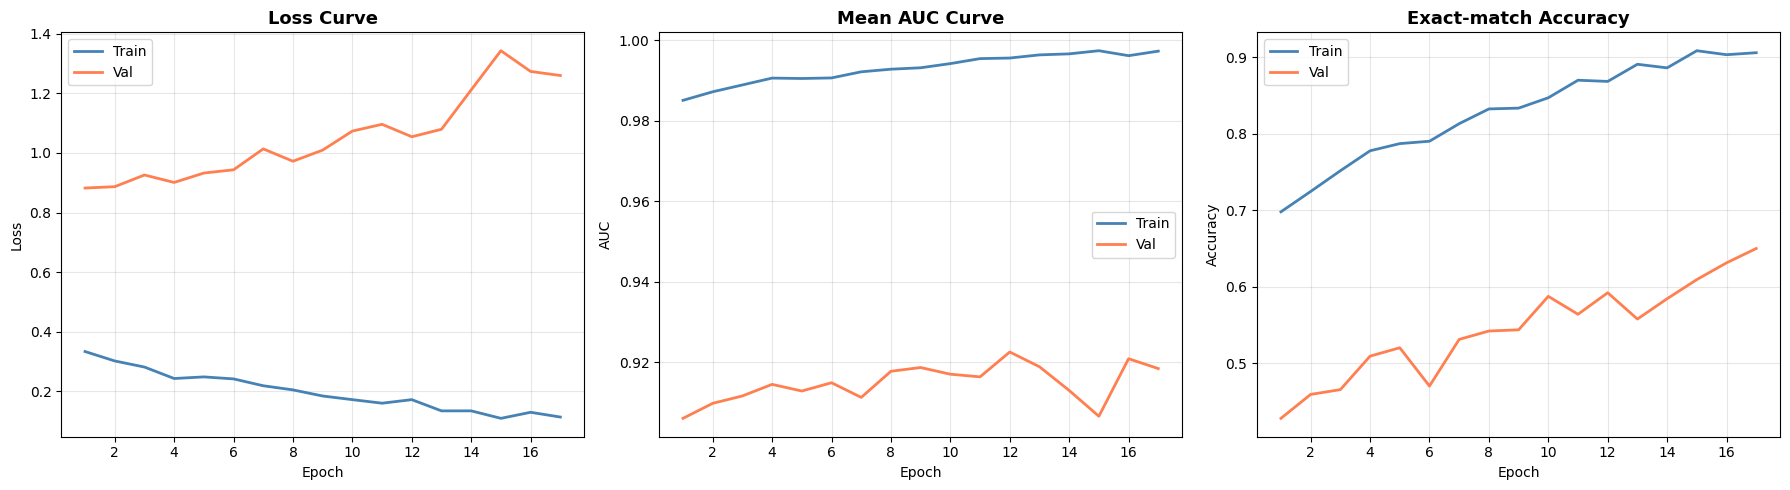

In [14]:
# ── Training curves: Loss + AUC + Accuracy ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(18,5))
epochs_ran = range(1, len(history['train_loss'])+1)

for ax, tr_key, vl_key, title, ylabel in [
    (axes[0], 'train_loss', 'val_loss', 'Loss Curve',              'Loss'),
    (axes[1], 'train_auc',  'val_auc',  'Mean AUC Curve',          'AUC'),
    (axes[2], 'train_acc',  'val_acc',  'Exact-match Accuracy',    'Accuracy')]:
    ax.plot(epochs_ran, history[tr_key], label='Train', color='steelblue', linewidth=2)
    ax.plot(epochs_ran, history[vl_key], label='Val',   color='coral',     linewidth=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── Optimal thresholds via Youden's J on validation ──────────
from sklearn.metrics import roc_curve

_, _, _, _, _, val_labels, val_probs = evaluate(model, val_loader, criterion, DEVICE)

optimal_thresholds = {}
print('Optimal thresholds (Youden J):')
print('-'*30)
for i, name in enumerate(DISEASE_COLS):
    fpr, tpr, threshs = roc_curve(val_labels[:,i], val_probs[:,i])
    best_t = float(np.clip(threshs[np.argmax(tpr - fpr)], 0.1, 0.9))
    optimal_thresholds[name] = best_t
    print(f'  {name:<6}: {best_t:.3f}')

Optimal thresholds (Youden J):
------------------------------
  DR    : 0.252
  ARMD  : 0.100
  MH    : 0.307
  DN    : 0.100
  MYA   : 0.100
  TSLN  : 0.100


In [16]:
# ── Full test set evaluation ──────────────────────────────────
_, _, _, _, _, test_labels, test_probs = evaluate(model, test_loader, criterion, DEVICE)

test_preds = np.zeros_like(test_probs, dtype=int)
for i, name in enumerate(DISEASE_COLS):
    test_preds[:,i] = (test_probs[:,i] >= optimal_thresholds[name]).astype(int)

print(f'\n{"Disease":<8} {"AUC":>6}  {"F1":>6}  {"Prec":>6}  {"Rec":>6}  {"Acc":>6}')
print('='*48)
results = {}
for i, name in enumerate(DISEASE_COLS):
    a  = roc_auc_score(test_labels[:,i], test_probs[:,i])
    f  = f1_score(test_labels[:,i], test_preds[:,i], zero_division=0)
    p  = precision_score(test_labels[:,i], test_preds[:,i], zero_division=0)
    r  = recall_score(test_labels[:,i], test_preds[:,i], zero_division=0)
    ac = accuracy_score(test_labels[:,i], test_preds[:,i])
    results[name] = dict(auc=a, f1=f, precision=p, recall=r, accuracy=ac)
    print(f'{name:<8} {a:>6.4f}  {f:>6.4f}  {p:>6.4f}  {r:>6.4f}  {ac:>6.4f}')
print('='*48)
mean_auc  = roc_auc_score(test_labels, test_probs, average='macro')
mean_f1   = f1_score(test_labels, test_preds, average='macro', zero_division=0)
mean_prec = precision_score(test_labels, test_preds, average='macro', zero_division=0)
mean_rec  = recall_score(test_labels, test_preds, average='macro', zero_division=0)
exact_acc = (test_preds == test_labels).all(axis=1).mean()
print(f'{"Mean":<8} {mean_auc:>6.4f}  {mean_f1:>6.4f}  {mean_prec:>6.4f}  {mean_rec:>6.4f}  {exact_acc:>6.4f}')


Disease     AUC      F1    Prec     Rec     Acc
DR       0.9345  0.7379  0.6446  0.8629  0.8812
ARMD     0.9499  0.5192  0.3699  0.8710  0.9219
MH       0.9636  0.7138  0.5818  0.9231  0.8797
DN       0.7451  0.2549  0.1646  0.5652  0.7625
MYA      0.9478  0.6923  0.5870  0.8438  0.9625
TSLN     0.9517  0.5935  0.4510  0.8679  0.9016
Mean     0.9154  0.5853  0.4665  0.8223  0.5109


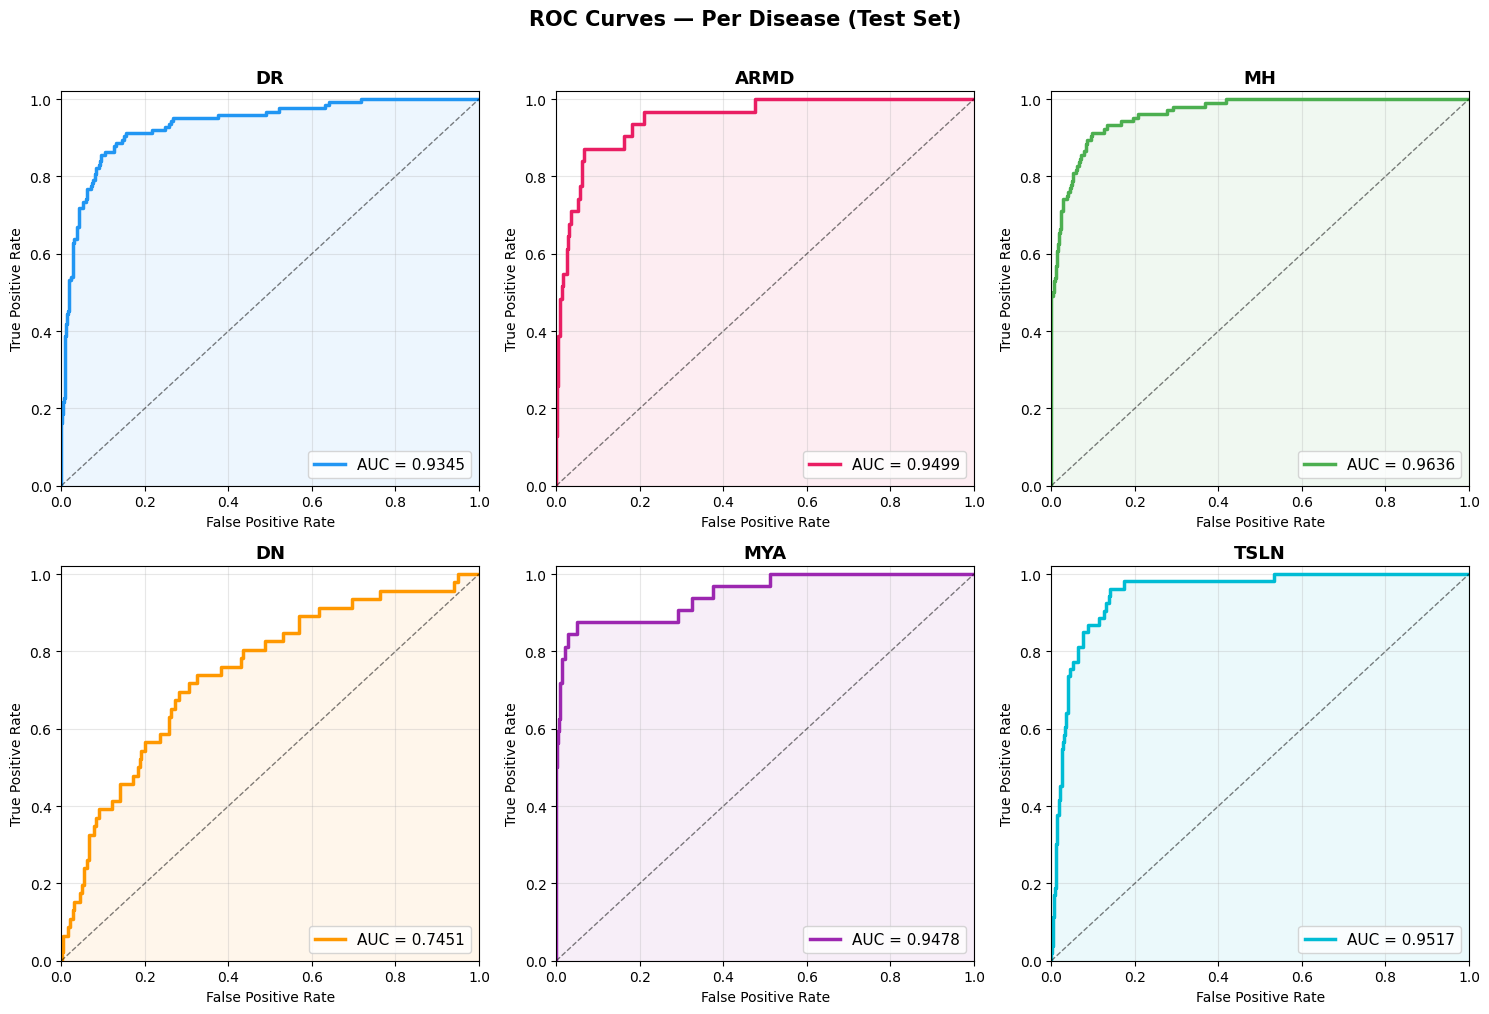

In [17]:
# ── Per-disease ROC curves ────────────────────────────────────
colors = ['#2196F3','#E91E63','#4CAF50','#FF9800','#9C27B0','#00BCD4']
fig, axes = plt.subplots(2, 3, figsize=(15,10))

for i, (name, ax) in enumerate(zip(DISEASE_COLS, axes.flatten())):
    fpr, tpr, _ = roc_curve(test_labels[:,i], test_probs[:,i])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i], linewidth=2.5, label=f'AUC = {roc_auc_val:.4f}')
    ax.plot([0,1],[0,1],'k--',linewidth=1,alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.08, color=colors[i])
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=11); ax.grid(alpha=0.3)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.suptitle('ROC Curves — Per Disease (Test Set)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

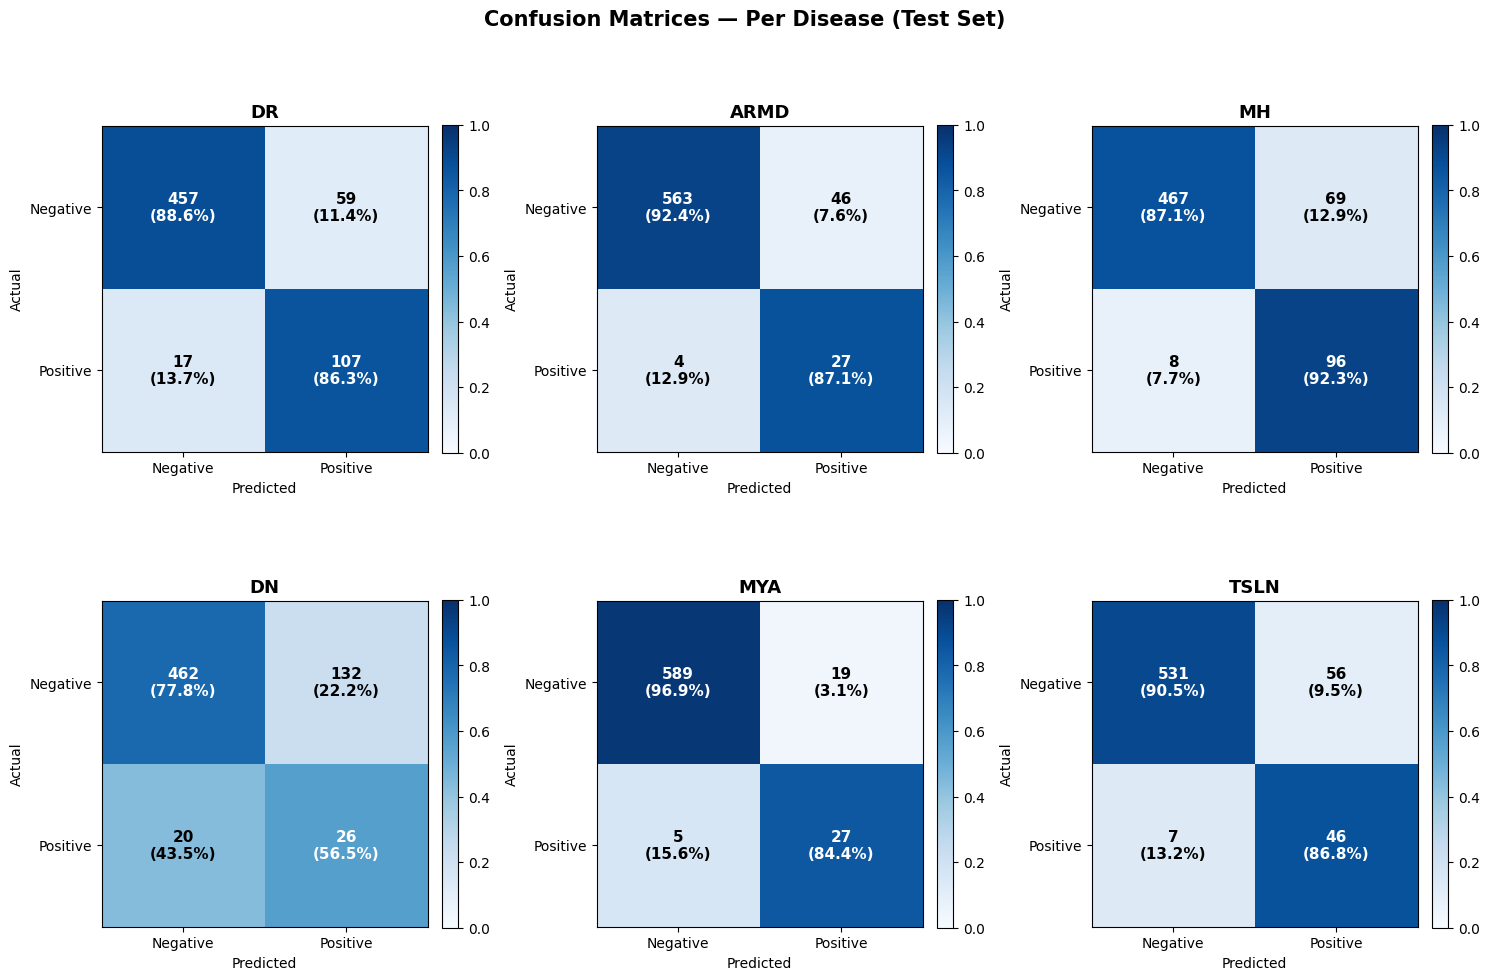

In [18]:
# ── Confusion matrix per disease ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15,10))

for i, (name, ax) in enumerate(zip(DISEASE_COLS, axes.flatten())):
    cm      = confusion_matrix(test_labels[:,i], test_preds[:,i])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Negative','Positive'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['Negative','Positive'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for r,c in itertools.product(range(2),range(2)):
        ax.text(c, r, f'{cm[r,c]}\n({cm_norm[r,c]:.1%})',
                ha='center', va='center', fontsize=11, fontweight='bold',
                color='white' if cm_norm[r,c]>0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Confusion Matrices — Per Disease (Test Set)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

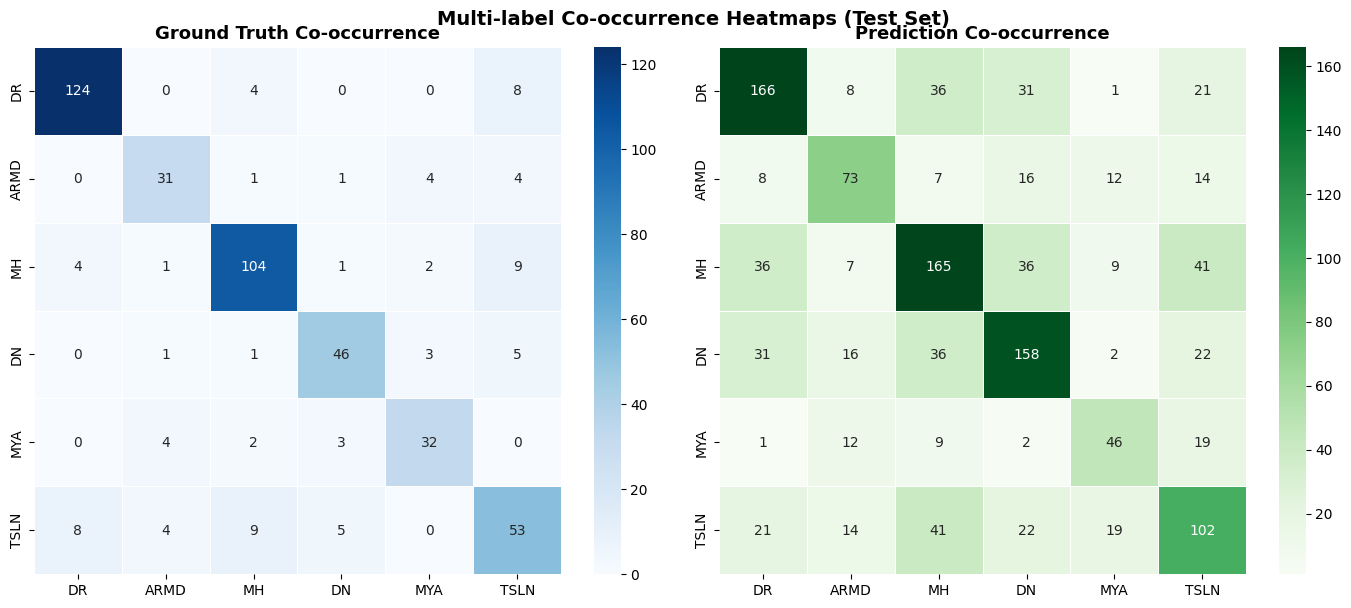

In [19]:
# ── Overall multi-label co-occurrence heatmaps ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.heatmap((test_labels.T @ test_labels).astype(int), annot=True, fmt='d',
            cmap='Blues', xticklabels=DISEASE_COLS, yticklabels=DISEASE_COLS,
            ax=axes[0], linewidths=0.5, square=True)
axes[0].set_title('Ground Truth Co-occurrence', fontsize=13, fontweight='bold')

sns.heatmap((test_preds.T @ test_preds).astype(int), annot=True, fmt='d',
            cmap='Greens', xticklabels=DISEASE_COLS, yticklabels=DISEASE_COLS,
            ax=axes[1], linewidths=0.5, square=True)
axes[1].set_title('Prediction Co-occurrence', fontsize=13, fontweight='bold')

plt.suptitle('Multi-label Co-occurrence Heatmaps (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cooccurrence_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

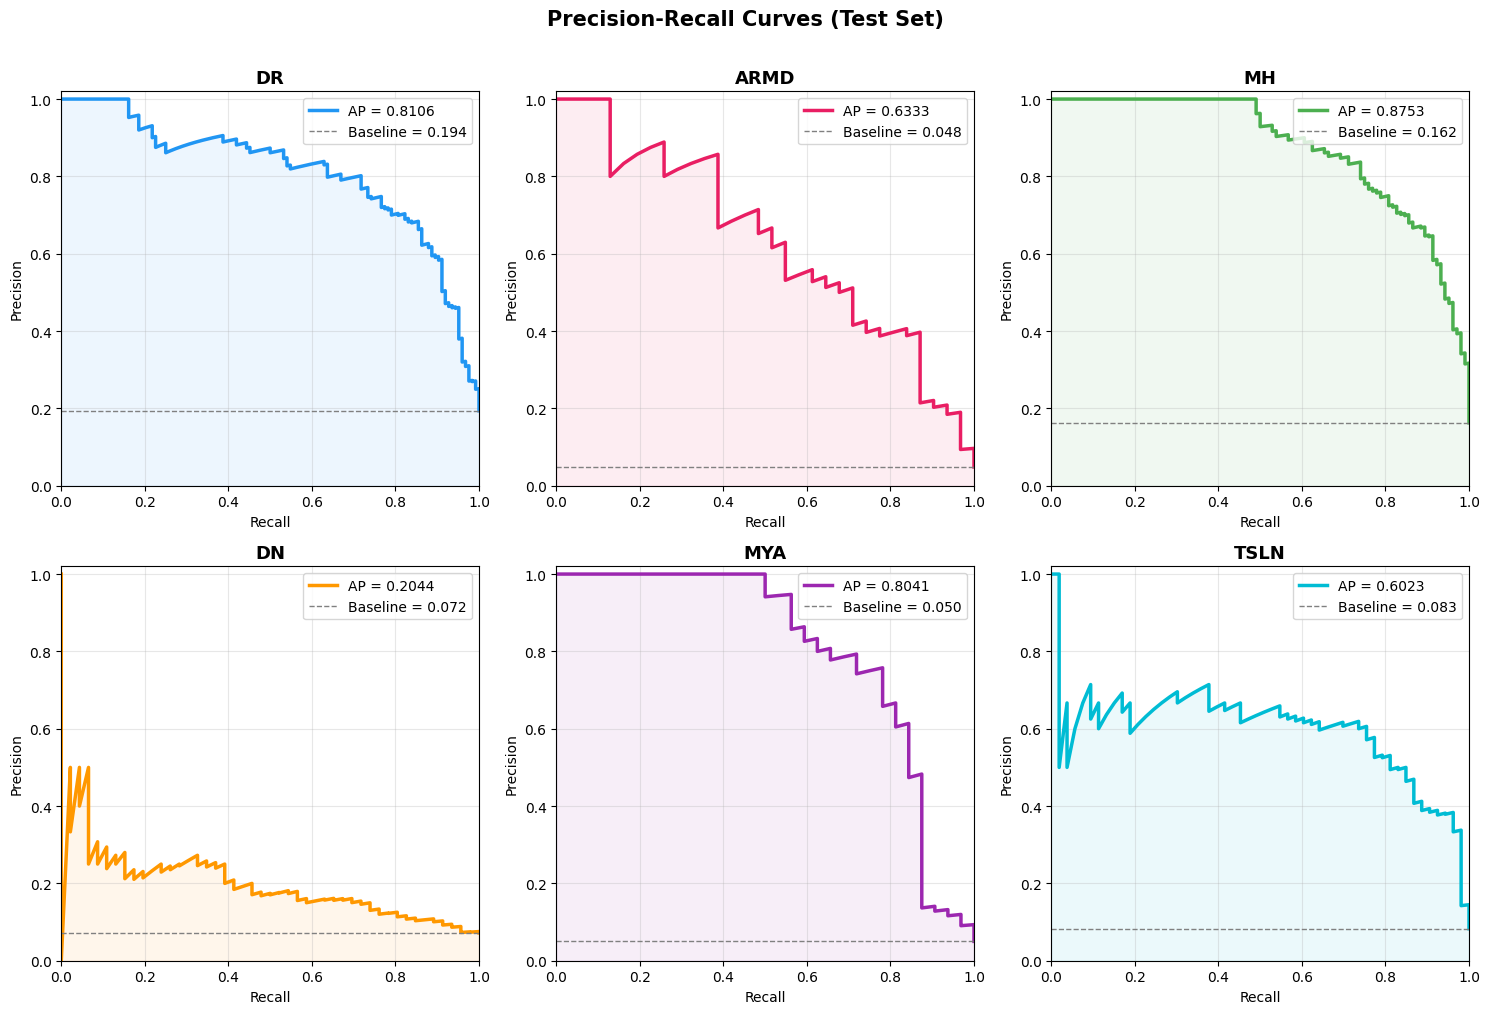

In [20]:
# ── Precision-Recall curves ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15,10))

for i, (name, ax) in enumerate(zip(DISEASE_COLS, axes.flatten())):
    prec_c, rec_c, _ = precision_recall_curve(test_labels[:,i], test_probs[:,i])
    ap = average_precision_score(test_labels[:,i], test_probs[:,i])
    baseline = test_labels[:,i].mean()
    ax.plot(rec_c, prec_c, color=colors[i], linewidth=2.5, label=f'AP = {ap:.4f}')
    ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1, label=f'Baseline = {baseline:.3f}')
    ax.fill_between(rec_c, prec_c, alpha=0.08, color=colors[i])
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.legend(loc='upper right', fontsize=10); ax.grid(alpha=0.3)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.suptitle('Precision-Recall Curves (Test Set)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

CLASSIFICATION REPORT — Per Disease (Test Set)

--- DR ---
              precision    recall  f1-score   support

       No DR     0.9641    0.8857    0.9232       516
          DR     0.6446    0.8629    0.7379       124

    accuracy                         0.8812       640
   macro avg     0.8044    0.8743    0.8306       640
weighted avg     0.9022    0.8812    0.8873       640


--- ARMD ---
              precision    recall  f1-score   support

     No ARMD     0.9929    0.9245    0.9575       609
        ARMD     0.3699    0.8710    0.5192        31

    accuracy                         0.9219       640
   macro avg     0.6814    0.8977    0.7384       640
weighted avg     0.9628    0.9219    0.9363       640


--- MH ---
              precision    recall  f1-score   support

       No MH     0.9832    0.8713    0.9238       536
          MH     0.5818    0.9231    0.7138       104

    accuracy                         0.8797       640
   macro avg     0.7825    0.8972    0.8188

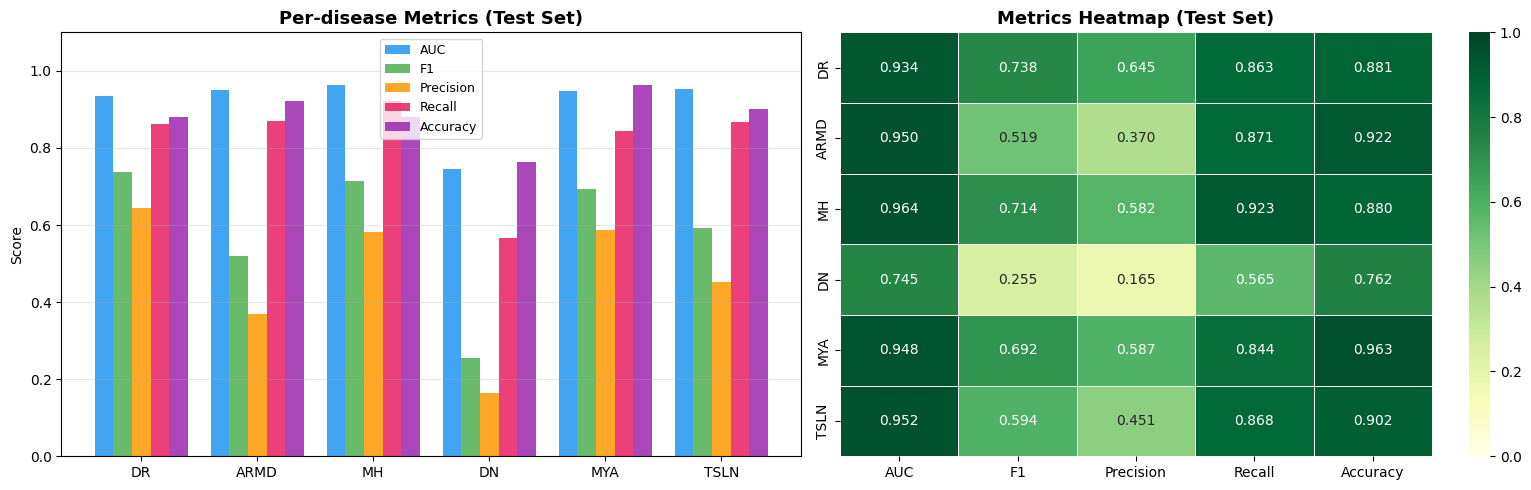

In [22]:
# ── Classification report ─────────────────────────────────────
print('='*60)
print('CLASSIFICATION REPORT — Per Disease (Test Set)')
print('='*60)
for name in DISEASE_COLS:
    i = DISEASE_COLS.index(name)
    print(f'\n--- {name} ---')
    print(classification_report(test_labels[:,i], test_preds[:,i],
          target_names=[f'No {name}', name], digits=4, zero_division=0))

# ── Metrics summary bar chart + heatmap ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16,5))
x = np.arange(len(DISEASE_COLS))
w = 0.16
for j,(key,color,label) in enumerate([
        ('auc','#2196F3','AUC'), ('f1','#4CAF50','F1'),
        ('precision','#FF9800','Precision'), ('recall','#E91E63','Recall'),
        ('accuracy','#9C27B0','Accuracy')]):
    vals = [results[d][key] for d in DISEASE_COLS]
    axes[0].bar(x + (j-2)*w, vals, width=w, label=label, color=color, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(DISEASE_COLS)
axes[0].set_ylim(0,1.1); axes[0].set_ylabel('Score')
axes[0].set_title('Per-disease Metrics (Test Set)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

metrics_matrix = np.array([[results[d][k] for k in ['auc','f1','precision','recall','accuracy']]
                             for d in DISEASE_COLS])
sns.heatmap(metrics_matrix, annot=True, fmt='.3f', cmap='YlGn',
            xticklabels=['AUC','F1','Precision','Recall','Accuracy'],
            yticklabels=DISEASE_COLS, vmin=0, vmax=1,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Metrics Heatmap (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_summary.png', dpi=150, bbox_inches='tight')
plt.show()

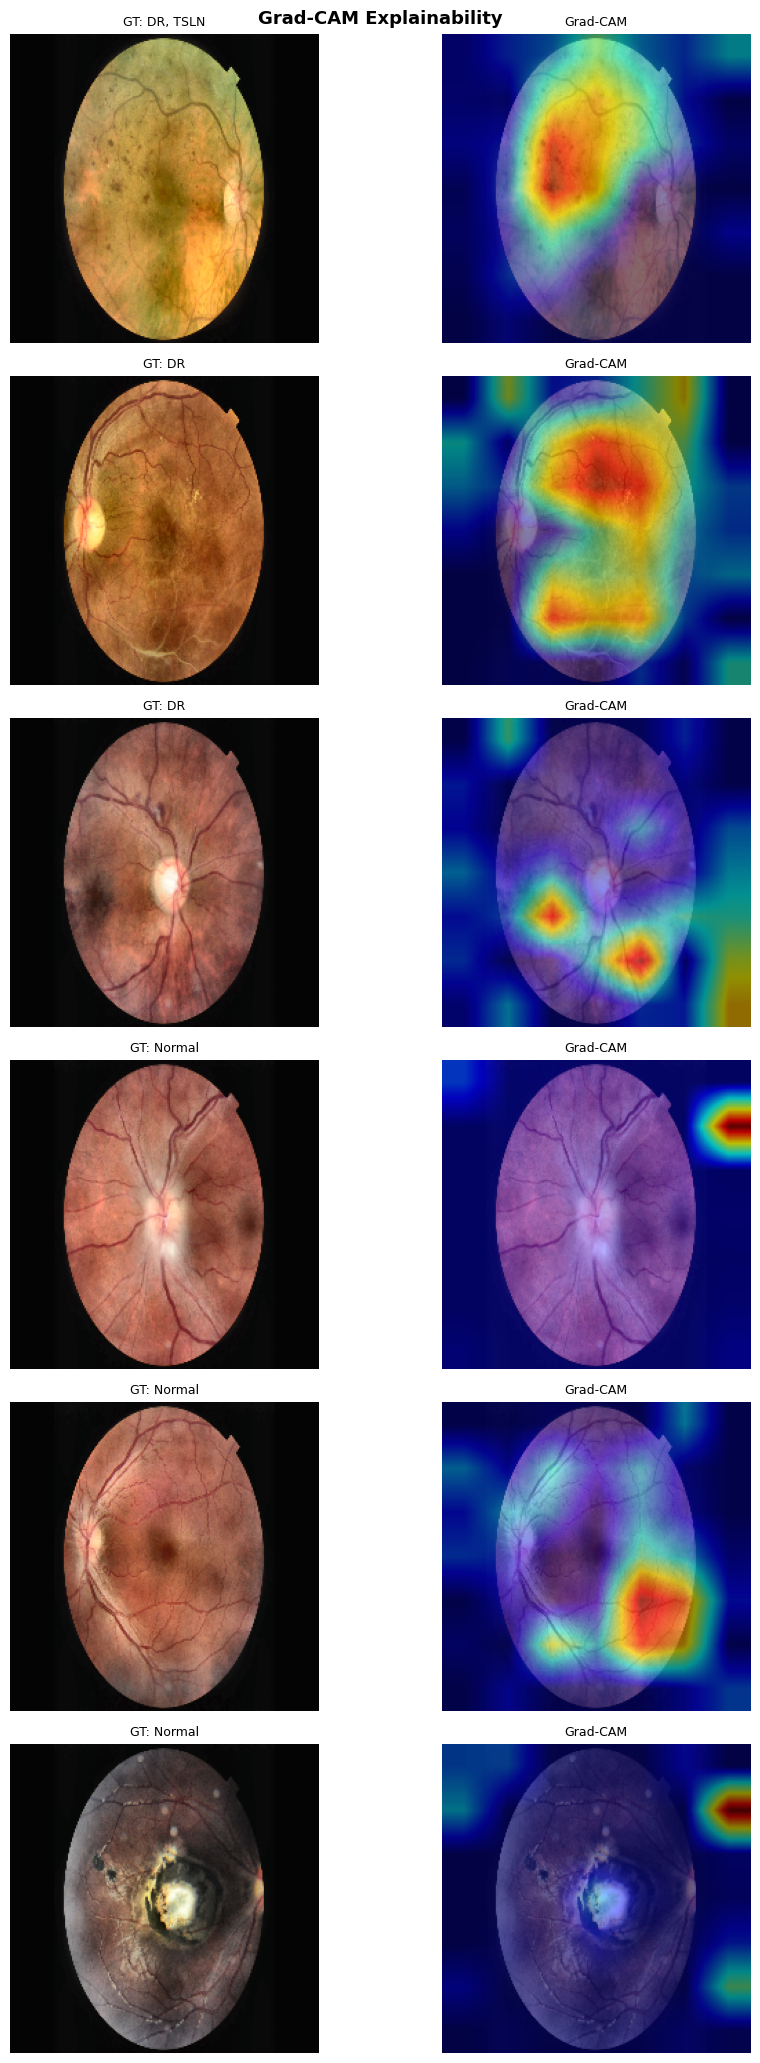

In [23]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

cam      = GradCAM(model=model, target_layers=[model.cnn.conv_head])
mean_np  = np.array([0.485, 0.456, 0.406])
std_np   = np.array([0.229, 0.224, 0.225])
sample_images, sample_labels = next(iter(test_loader))
n_show   = min(6, len(sample_images))

fig, axes = plt.subplots(n_show, 2, figsize=(10, n_show * 3.5))
for i in range(n_show):
    inp  = sample_images[i].unsqueeze(0).to(DEVICE)
    mask = cam(input_tensor=inp)
    img_display = np.clip(
        sample_images[i].permute(1,2,0).numpy() * std_np + mean_np,
        0, 1).astype(np.float32)
    cam_image = show_cam_on_image(img_display, mask[0], use_rgb=True)
    lbl      = sample_labels[i].numpy().astype(int)
    diseases = [DISEASE_COLS[j] for j, v in enumerate(lbl) if v]
    title    = ', '.join(diseases) if diseases else 'Normal'
    axes[i,0].imshow(img_display)
    axes[i,0].set_title(f'GT: {title}', fontsize=9)
    axes[i,0].axis('off')
    axes[i,1].imshow(cam_image)
    axes[i,1].set_title('Grad-CAM', fontsize=9)
    axes[i,1].axis('off')
plt.suptitle('Grad-CAM Explainability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_v3.png', dpi=150, bbox_inches='tight')
plt.show()